Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

In [ ]:
df = pd.read_csv('/content/ML project Dataset.zip')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
df = df.dropna()
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes':1, 'No':0})

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

# Final Random Forest (tuned)
rf = RandomForestClassifier(max_depth=10, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
models = {
    "Logistic": pred_lr,
    "KNN": pred_knn,
    "Decision Tree": pred_dt,
    "SVM": pred_svm,
    "Random Forest": pred_rf
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    TN, FP, FN, TP = cm.ravel()

    print("\n🔹", name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Sensitivity:", recall_score(y_test, pred))
    print("Specificity:", TN / (TN + FP))
    print("F1 Score:", f1_score(y_test, pred))


🔹 Logistic
Accuracy: 0.8559907834101382
Precision: 0.7396878483835005
Sensitivity: 0.5340040241448692
Specificity: 0.9469257870212524
F1 Score: 0.620238373451741

🔹 KNN
Accuracy: 0.8418114143920595
Precision: 0.6845991561181435
Sensitivity: 0.5223340040241449
Specificity: 0.9320377315604046
F1 Score: 0.5925587765350376

🔹 Decision Tree
Accuracy: 0.794221907125133
Precision: 0.5318235064427957
Sensitivity: 0.5480885311871228
Specificity: 0.8637345152858279
F1 Score: 0.539833531510107

🔹 SVM
Accuracy: 0.8606876993973768
Precision: 0.7833643699565487
Sensitivity: 0.5078470824949698
Specificity: 0.9603364018638482
F1 Score: 0.6162109375

🔹 Random Forest
Accuracy: 0.8565225097483162
Precision: 0.7761479591836735
Sensitivity: 0.489738430583501
Specificity: 0.960109103307194
F1 Score: 0.6005428077966938


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    specificity = TN / (TN + FP)
    f1 = f1_score(y_test, pred)

    results.append([name, accuracy, precision, recall, specificity, f1])

# Create DataFrame
df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"
])

df_results.style.highlight_max(axis=0)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score
0,Logistic,0.855991,0.739688,0.534004,0.946926,0.620238
1,KNN,0.841811,0.684599,0.522334,0.932038,0.592559
2,Decision Tree,0.794222,0.531824,0.548089,0.863735,0.539834
3,SVM,0.860688,0.783364,0.507847,0.960336,0.616211
4,Random Forest,0.856523,0.776148,0.489738,0.960109,0.600543


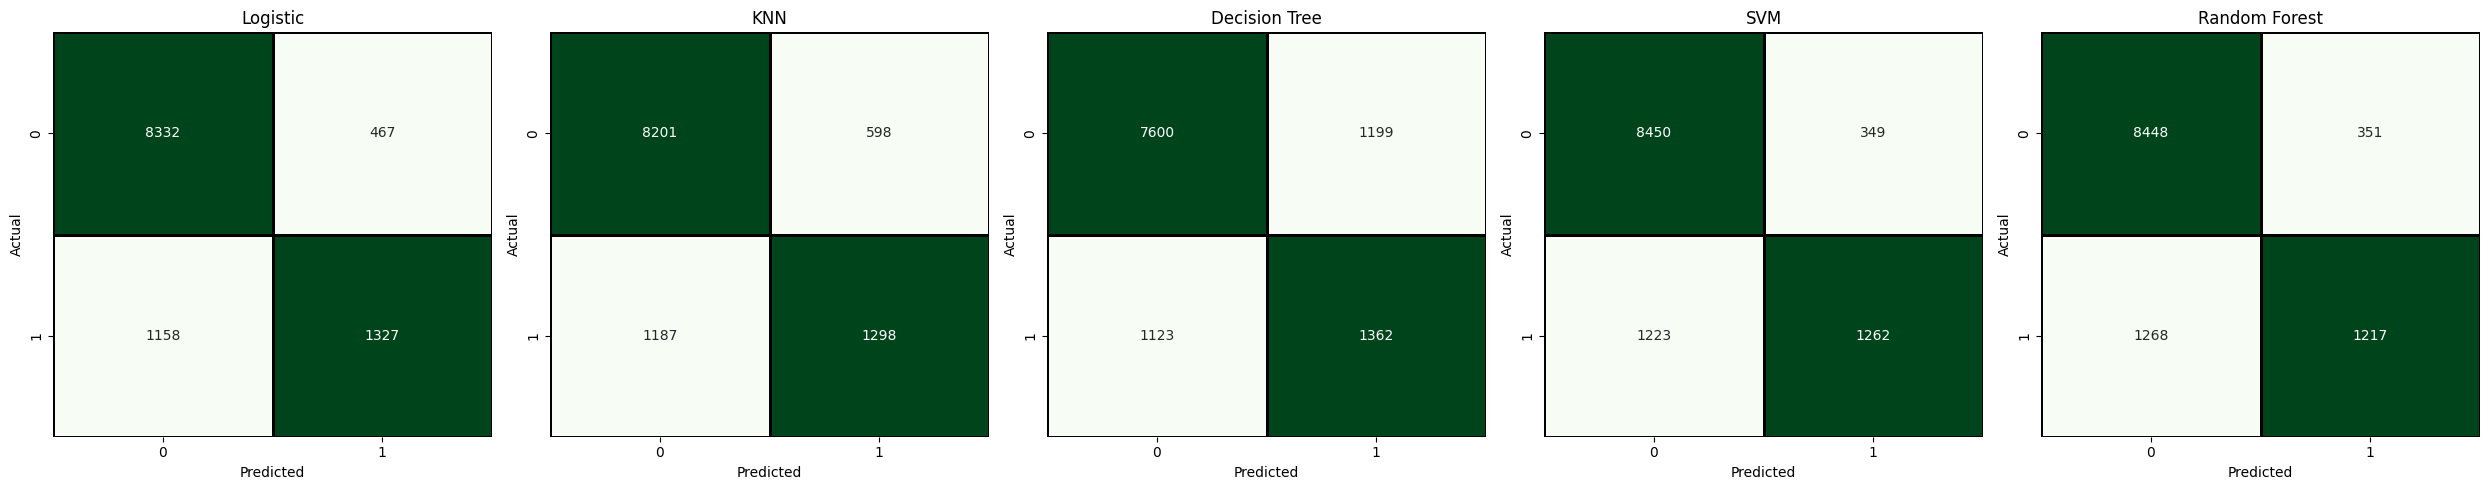

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)

    color_matrix = np.zeros_like(cm)
    np.fill_diagonal(color_matrix, 1)

    sns.heatmap(color_matrix, annot=cm, fmt='d', cmap='Greens',
                cbar=False, ax=ax, linewidths=2, linecolor='black')

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

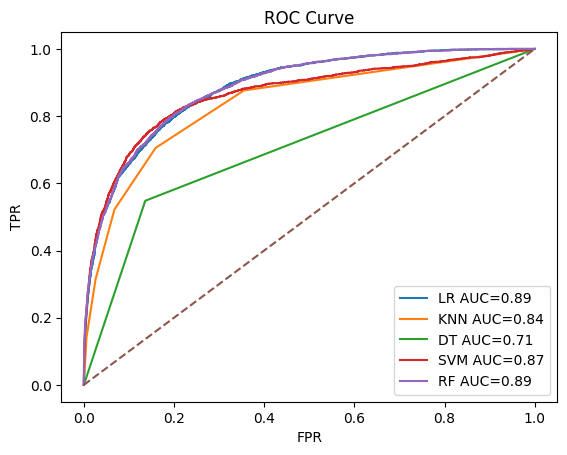

In [ ]:
plt.figure()

lr_prob = lr.predict_proba(X_test)[:,1]
knn_prob = knn.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
svm_prob = svm.decision_function(X_test)

for prob, name in [
    (lr_prob, "LR"),
    (knn_prob, "KNN"),
    (dt_prob, "DT"),
    (svm_prob, "SVM"),
    (rf_prob, "RF")
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name + " AUC=%.2f" % auc(fpr, tpr))

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

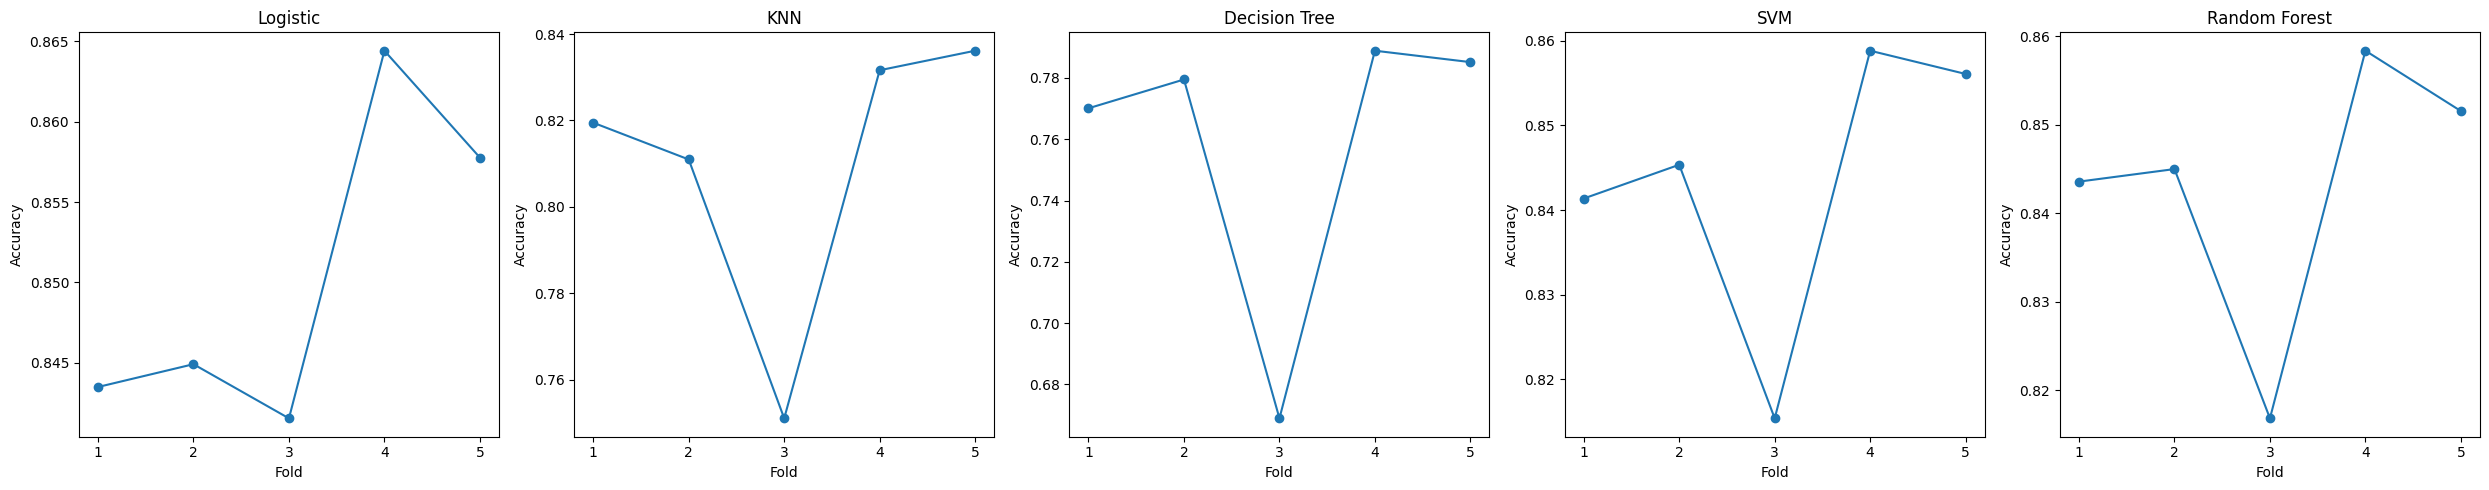

In [ ]:
models_cv = {
    "Logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": make_pipeline(StandardScaler(), SVC()),
    "Random Forest": RandomForestClassifier(max_depth=10)
}

fig, axes = plt.subplots(1, 5, figsize=(25,5))

for ax, (name, model) in zip(axes, models_cv.items()):
    scores = cross_val_score(model, X, y, cv=5)

    ax.plot(range(1,6), scores, marker='o')
    ax.set_title(name)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(1,6))

plt.tight_layout()
plt.show()

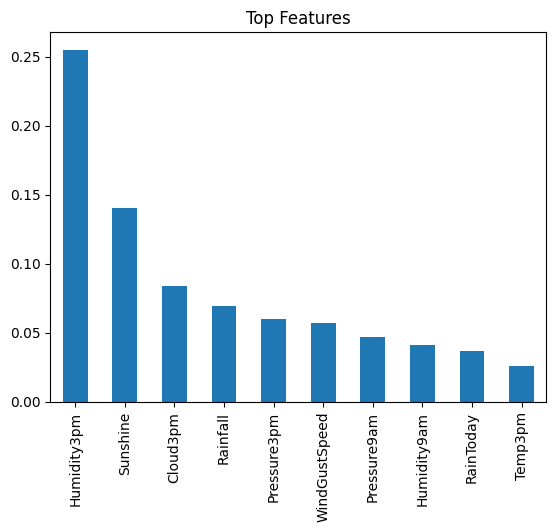

In [ ]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

pd.Series(importance, index=features).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [ ]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8902428216944346
Testing Accuracy: 0.8565225097483162


In [ ]:
# The original X_test was transformed by StandardScaler, converting it to a NumPy array,
# which no longer has a .index attribute like a DataFrame.
# To get the original sample, we need to access the index from the DataFrame version of X_test.
# We'll temporarily re-run train_test_split to get the original DataFrame X_test without scaling.
from sklearn.model_selection import train_test_split

# Assuming X and y are the globally defined DataFrames/Series from the earlier split
_, X_test_df_original, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, get the actual original index of the first sample in this unscaled test DataFrame
original_index_of_first_test_sample = X_test_df_original.index[0]

# Retrieve the original unscaled sample from the main DataFrame X using its original index
original_sample = X.loc[original_index_of_first_test_sample]
print(original_sample)

Date             1443.0
Location            3.0
MinTemp             7.7
MaxTemp            24.2
Rainfall            0.0
Evaporation         4.8
Sunshine           13.2
WindGustDir         6.0
WindGustSpeed      39.0
WindDir9am          6.0
WindDir3pm          7.0
WindSpeed9am        9.0
WindSpeed3pm       20.0
Humidity9am        67.0
Humidity3pm        39.0
Pressure9am      1018.4
Pressure3pm      1014.0
Cloud9am            1.0
Cloud3pm            3.0
Temp9am            13.5
Temp3pm            22.7
RainToday           0.0
Name: 47050, dtype: float64


In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Rain Tomorrow: YES")
else:
    print("Rain Tomorrow: NO")

Rain Tomorrow: NO
